 *Artificial Intelligence for Vision & NLP* &nbsp; | &nbsp;  *ATU Donegal - Postgrad Diploma in Big Data Analytics & Artificial Intelligence*

# Student Submisison 
Name           : John Ryan         <br>
Student Number : L00007202         <br>
Due Date       : 12th May 2026     <br>
Assignment     : CA2               <br>
Module         : AI for Vision and NLP    <br>
Course         : Postgraduate Diploma in Big Data Analytics and AI

## NLP and Vision Pipeline : High Level
An image of your working pipeline at high level can be inserted here



# Initialisation
Perform pip installs(or use a requirements.txt) <br>
perform imports

## Install packages

In [2]:
# pip installs
# pip install -r requirements.txt

## Imports

In [1]:
# imports
import pandas as pd

# Support Functions

In [ ]:
# code here

# NLP

## Tokenisation

In [1]:
## code
import pymupdf  
import nltk
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('punkt_tab')

# ── 1. Extract text from PDF ──────────────────────────────────────────────────
pdf_path = "CA2 - Application_2026.pdf"

doc = pymupdf.open(pdf_path)

full_text = ""
for page in doc:
    full_text += page.get_text()

doc.close()

print("=== RAW TEXT PREVIEW (first 200 chars) ===")
print(full_text[:200])

# ── 2. Tokenise ───────────────────────────────────────────────────────────────
tokens = word_tokenize(full_text)

print(f"\n=== TOKEN COUNT ===")
print(f"Total tokens (including punctuation): {len(tokens)}")

# ── 3. Word-only tokens (optional, cleaner count) ─────────────────────────────
word_tokens = [t for t in tokens if t.isalpha()]

print(f"Word-only tokens (no punctuation/numbers): {len(word_tokens)}")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\jryan\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\jryan\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


=== RAW TEXT PREVIEW (first 500 chars) ===
 
AI for Vision & NLP 
CA2 - Application 
 
Assignment: 
AI for Vision and NLP – CA2: Application 
Learning 
Outcomes: 
 
Differentiate between Text Analytics and NLP systems. 
 
Critique, analyse a

=== TOKEN COUNT ===
Total tokens (including punctuation): 1369
Word-only tokens (no punctuation/numbers): 1115


In [3]:
print(len(full_text))

7845


## Removing Stopwords
Using NLTK as next step is stemming

In [2]:
from nltk.corpus import stopwords
#import nltk

nltk.download('stopwords')

# ── 1. Load English stopwords ─────────────────────────────────────────────────
stop_words = set(stopwords.words('english'))

print(f"Number of default NLTK stopwords: {len(stop_words)}")

# ── 2. Remove stopwords from your word tokens ─────────────────────────────────
# Using word_tokens from step 4 (alphabetic tokens only)
filtered_tokens = [t for t in word_tokens if t.lower() not in stop_words]

print(f"\n=== STOPWORD REMOVAL RESULTS ===")
print(f"Tokens before removal : {len(word_tokens)}")
print(f"Tokens after removal  : {len(filtered_tokens)}")
print(f"Stopwords removed     : {len(word_tokens) - len(filtered_tokens)}")

# ── 3. Preview ────────────────────────────────────────────────────────────────
print(f"\nSample tokens before: {word_tokens[:10]}")
print(f"Sample tokens after : {filtered_tokens[:10]}")

# ── 4. Optional: add custom stopwords relevant to your document ───────────────
custom_stopwords = {'page', 'figure', 'table', 'et', 'al', 'also'}
stop_words.update(custom_stopwords)

filtered_tokens_custom = [t for t in word_tokens if t.lower() not in stop_words]

print(f"\nTokens after custom stopword removal: {len(filtered_tokens_custom)}")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jryan\AppData\Roaming\nltk_data...


Number of default NLTK stopwords: 198

=== STOPWORD REMOVAL RESULTS ===
Tokens before removal : 1115
Tokens after removal  : 677
Stopwords removed     : 438

Sample tokens before: ['AI', 'for', 'Vision', 'NLP', 'Application', 'Assignment', 'AI', 'for', 'Vision', 'and']
Sample tokens after : ['AI', 'Vision', 'NLP', 'Application', 'Assignment', 'AI', 'Vision', 'NLP', 'Application', 'Learning']

Tokens after custom stopword removal: 677


[nltk_data]   Unzipping corpora\stopwords.zip.


## Stemming

In [6]:
from nltk.stem import PorterStemmer, LancasterStemmer
from nltk.tokenize import word_tokenize

# ── 1. Initialise the stemmers ────────────────────────────────────────────────
porter   = PorterStemmer()
lancaster = LancasterStemmer()

# ── 2. Apply stemming to filtered tokens (from your stopword removal step) ────
porter_stemmed   = [porter.stem(token)   for token in filtered_tokens]
lancaster_stemmed = [lancaster.stem(token) for token in filtered_tokens]

# ── 3. Preview results ────────────────────────────────────────────────────────
print("=== STEMMING COMPARISON (first 10 tokens) ===")
print(f"{'Original':<20} {'Porter':<20} {'Lancaster':<20}")
print("-" * 80)
for original, p, l in zip(filtered_tokens[:10], 
                               porter_stemmed[:10], 
                               lancaster_stemmed[:10]):
    print(f"{original:<20} {p:<20} {l:<20}")

# ── 4. Unique stem count comparison ──────────────────────────────────────────
print(f"\n=== UNIQUE STEM COUNTS ===")
print(f"Original unique tokens : {len(set(filtered_tokens))}")
print(f"Porter unique stems    : {len(set(porter_stemmed))}")
print(f"Lancaster unique stems  : {len(set(lancaster_stemmed))}")

=== STEMMING COMPARISON (first 10 tokens) ===
Original             Porter               Lancaster           
--------------------------------------------------------------------------------
AI                   ai                   ai                  
Vision               vision               vis                 
NLP                  nlp                  nlp                 
Application          applic               apply               
Assignment           assign               assign              
AI                   ai                   ai                  
Vision               vision               vis                 
NLP                  nlp                  nlp                 
Application          applic               apply               
Learning             learn                learn               

=== UNIQUE STEM COUNTS ===
Original unique tokens : 377
Porter unique stems    : 282
Lancaster unique stems  : 270


## Lemmatisation

In [7]:
import spacy

# ── 1. Load spaCy model ───────────────────────────────────────────────────────
# Run in terminal if not already downloaded: python -m spacy download en_core_web_sm
nlp = spacy.load("en_core_web_sm")

# ── 2. Process filtered_tokens from your NLTK stopword step ──────────────────
# Join filtered_tokens back into a string for spaCy to process
filtered_text = " ".join(filtered_tokens)
doc_spacy = nlp(filtered_text)

# ── 3. Extract lemmas ─────────────────────────────────────────────────────────
lemmatised_tokens = [token.lemma_.lower() for token in doc_spacy
                     if token.is_alpha]

# ── 4. Preview results ────────────────────────────────────────────────────────
print("=== LEMMATISATION RESULTS ===")
print(f"{'Original':<20} {'Lemma':<20}")
print("-" * 40)
for original, lemma in zip(filtered_tokens[:15], lemmatised_tokens[:15]):
    print(f"{original:<20} {lemma:<20}")

# ── 5. Compare token counts ───────────────────────────────────────────────────
print(f"\n=== TOKEN COUNT COMPARISON ===")
print(f"Unique tokens (pre-lemma)  : {len(set(filtered_tokens))}")
print(f"Unique tokens (post-lemma) : {len(set(lemmatised_tokens))}")

# ── 6. Compare stemming vs lemmatisation side by side ─────────────────────────
print(f"\n=== STEMMING vs LEMMATISATION COMPARISON (first 15 tokens) ===")
print(f"{'Original':<20} {'Porter Stem':<20} {'Snowball Stem':<20} {'Lemma':<20}")
print("-" * 80)
for original, p, s, lemma in zip(filtered_tokens[:15],
                                  porter_stemmed[:15],
                                  snowball_stemmed[:15],
                                  lemmatised_tokens[:15]):
    print(f"{original:<20} {p:<20} {s:<20} {lemma:<20}")

=== LEMMATISATION RESULTS ===
Original             Lemma               
----------------------------------------
AI                   ai                  
Vision               vision              
NLP                  nlp                 
Application          application         
Assignment           assignment          
AI                   ai                  
Vision               vision              
NLP                  nlp                 
Application          application         
Learning             learning            
Outcomes             outcomes            
Differentiate        differentiate       
Text                 text                
Analytics            analytic            
NLP                  nlp                 

=== TOKEN COUNT COMPARISON ===
Unique tokens (pre-lemma)  : 377
Unique tokens (post-lemma) : 308

=== STEMMING vs LEMMATISATION COMPARISON (first 15 tokens) ===
Original             Porter Stem          Snowball Stem        Lemma               
-----------

## TF-IDF

=== TF-IDF SCORES ===
              and  application     as     be   code  image  images     in  \
Document 1  0.595        0.068  0.094  0.145  0.111  0.102   0.085  0.094   

            meaningful   must    of  of the     or  presentation  system  \
Document 1       0.068  0.102  0.23   0.102  0.128         0.068   0.085   

            text  text and    the     to   will  
Document 1  0.23     0.077  0.604  0.196  0.068  

=== TOP TERMS ===
              Document 1
the             0.603911
and             0.595405
of              0.229656
text            0.229656
to              0.195633
be              0.144598
or              0.127587
code            0.110575
of the          0.102069
image           0.102069
must            0.102069
as              0.093564
in              0.093564
system          0.085058
images          0.085058
text and        0.076552
application     0.068046
meaningful      0.068046
presentation    0.068046
will            0.068046


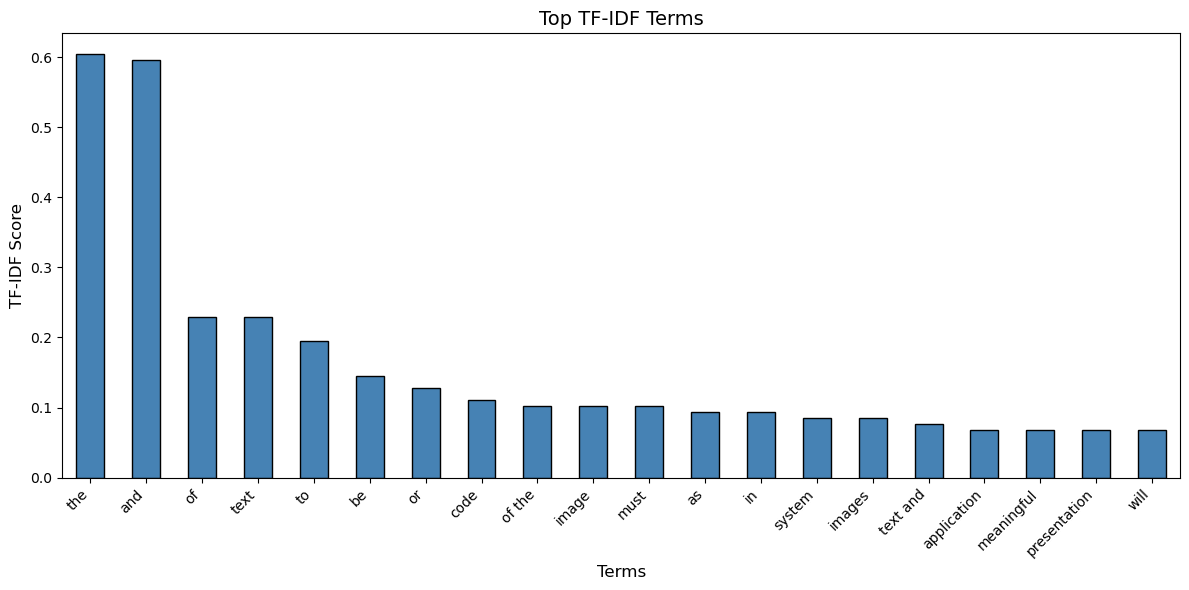

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import matplotlib.pyplot as plt

# ── 1. Prepare your corpus ────────────────────────────────────────────────────
# Each document is one entry in the list
# For now we have one, but you can simply append more later
#corpus = [processed_text]  # processed_text = " ".join(lemmatised_tokens)
corpus = [full_text]  # 
#corpus = [processed_text, processed_text_doc2, processed_text_doc3]

# ── 2. Initialise and fit the TF-IDF Vectorizer ───────────────────────────────
vectorizer = TfidfVectorizer(
    max_features=20,      # top 20 features
    ngram_range=(1, 2)    # single words and bigrams
)

tfidf_matrix = vectorizer.fit_transform(corpus)

# ── 3. Get feature names and scores ──────────────────────────────────────────
feature_names = vectorizer.get_feature_names_out()

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=feature_names,
    index=[f"Document {i+1}" for i in range(len(corpus))]
)

print("=== TF-IDF SCORES ===")
print(tfidf_df.round(3))

# ── 4. Top terms ──────────────────────────────────────────────────────────────
top_terms = tfidf_df.T.sort_values("Document 1", ascending=False)

print("\n=== TOP TERMS ===")
print(top_terms)

# ── 5. Visualise ──────────────────────────────────────────────────────────────
plt.figure(figsize=(12, 6))
top_terms["Document 1"].plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top TF-IDF Terms', fontsize=14)
plt.xlabel('Terms', fontsize=12)
plt.ylabel('TF-IDF Score', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Vision

## Sub Heading 1

In [ ]:
# code here...

# Multi-modal

## Sub Heading 1

In [ ]:
# code here

# Final Output

In [ ]:
# code